# Introduction

Do higher film budgets lead to more box office revenue? Let's find out if there's a relationship using the movie budgets and financial performance data that I've scraped from [the-numbers.com](https://www.the-numbers.com/movie/budgets) on **May 1st, 2018**. 

<img src=https://i.imgur.com/kq7hrEh.png>

# Import Statements

In [29]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 10.7 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 11.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 11.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Read the Data

In [3]:
data = pd.read_csv('cost_revenue_dirty.csv')

# Explore and Clean the Data

**Challenge**: Answer these questions about the dataset:
1. How many rows and columns does the dataset contain?
2. Are there any NaN values present?
3. Are there any duplicate rows?
4. What are the data types of the columns?

In [4]:
#1. How many rows and columns does the dataset contain?
print(data.shape)
# 2. Are there any NaN values present?
print(data.isna().any().any()) # Well there seems to be no NaN values present
# 3. Are there any duplicate rows?
print(data.duplicated().sum()) # There seems to be no duplicate rows
# 4. What are the data types of the columns?
print(data.dtypes)

(5391, 6)
False
0
Rank                     int64
Release_Date               str
Movie_Title                str
USD_Production_Budget      str
USD_Worldwide_Gross        str
USD_Domestic_Gross         str
dtype: object


### Data Type Conversions

**Challenge**: Convert the `USD_Production_Budget`, `USD_Worldwide_Gross`, and `USD_Domestic_Gross` columns to a numeric format by removing `$` signs and `,`. 
<br>
<br>
Note that *domestic* in this context refers to the United States.

In [5]:
data["USD_Production_Budget"] = (
    data["USD_Production_Budget"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

data["USD_Worldwide_Gross"] = (
    data["USD_Worldwide_Gross"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

data["USD_Domestic_Gross"] = (
    data["USD_Domestic_Gross"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)


print(data["USD_Production_Budget"])
print(data["USD_Worldwide_Gross"])
print(data["USD_Domestic_Gross"])

0          110000
1          385907
2          200000
3          100000
4          245000
          ...    
5386     15000000
5387    160000000
5388    175000000
5389     50000000
5390     20000000
Name: USD_Production_Budget, Length: 5391, dtype: int64
0       11000000
1              0
2        8000000
3        3000000
4       22000000
          ...   
5386           0
5387           0
5388           0
5389           0
5390           0
Name: USD_Worldwide_Gross, Length: 5391, dtype: int64
0       10000000
1              0
2        8000000
3        3000000
4       11000000
          ...   
5386           0
5387           0
5388           0
5389           0
5390           0
Name: USD_Domestic_Gross, Length: 5391, dtype: int64


**Challenge**: Convert the `Release_Date` column to a Pandas Datetime type. 

In [6]:
# converting Release_Date column to Pandas Datetime type from str
data["Release_Date"] = pd.to_datetime(data["Release_Date"])

# Checking
print(data["Release_Date"].dtypes)

datetime64[us]


### Descriptive Statistics

**Challenge**: 

1. What is the average production budget of the films in the data set?
2. What is the average worldwide gross revenue of films?
3. What were the minimums for worldwide and domestic revenue?
4. Are the bottom 25% of films actually profitable or do they lose money?
5. What are the highest production budget and highest worldwide gross revenue of any film?
6. How much revenue did the lowest and highest budget films make?

In [7]:
# Average productin budget of the films in the data set
print(f"Average Produciton budget = {data["USD_Production_Budget"].mean()}")

# Average World wide gross
print(f"Average Worldwide gross = {data["USD_Worldwide_Gross"].mean()}")

# USA world wide gross
print(f"USA world wide gross = {data["USD_Worldwide_Gross"].min()}")

print(f"USA domestic gross = {data["USD_Domestic_Gross"].min()}")

# Bottom 25% check
# 1. Calculate the 25th percentile threshold
threshold = data["USD_Worldwide_Gross"].quantile(0.25)

# 2. Filter the DataFrame for the bottom 25%
bottom_25_percent = data[data["USD_Worldwide_Gross"] <= threshold]

if (bottom_25_percent["USD_Worldwide_Gross"].sum() / bottom_25_percent["USD_Production_Budget"].sum()) < 1:
    print("Bottom 25 % percent of movies are not profitable")
else:
    print("Bottom 25 % percent of movies are profitable")



# Highest production budget
print("Highest Production Budget = ", end="")
print(data.loc[data["USD_Production_Budget"] == data["USD_Production_Budget"].max()])

# Highest world wide gross revenue
print("Highest World Wide Gross Revenue = ", end="")
print(data.loc[data["USD_Worldwide_Gross"] == data["USD_Worldwide_Gross"].max()])


# How much revenue did lowest and highest budget films made

# Highest budget revenude
print("Highest Production Budget Revenue= ", end="")
print(data.loc[
    data["USD_Production_Budget"] == data["USD_Production_Budget"].max()
               ])

# Lowest budget revenude
print("Lowest Production Budget Revenue= ", end="")
print(data.loc[
    data["USD_Production_Budget"] == data["USD_Production_Budget"].min()
               ])

Average Produciton budget = 31113737.57837136
Average Worldwide gross = 88855421.96271564
USA world wide gross = 0
USA domestic gross = 0
Bottom 25 % percent of movies are not profitable
Highest Production Budget =       Rank Release_Date Movie_Title  USD_Production_Budget  \
3529     1   2009-12-18      Avatar              425000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
3529           2783918982           760507625  
Highest World Wide Gross Revenue =       Rank Release_Date Movie_Title  USD_Production_Budget  \
3529     1   2009-12-18      Avatar              425000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
3529           2783918982           760507625  
Highest Production Budget Revenue=       Rank Release_Date Movie_Title  USD_Production_Budget  \
3529     1   2009-12-18      Avatar              425000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
3529           2783918982           760507625  
Lowest Production Budget Revenue=       Rank Release

# Investigating the Zero Revenue Films

**Challenge** How many films grossed $0 domestically (i.e., in the United States)? What were the highest budget films that grossed nothing?

In [8]:
print(len(data.loc[data["USD_Domestic_Gross"] == 0]))

made_nothing = data.loc[
    data["USD_Domestic_Gross"] == data["USD_Domestic_Gross"].min()
]

result = made_nothing.loc[
    made_nothing["USD_Production_Budget"] == made_nothing["USD_Production_Budget"].max()
]

print(result)

512
      Rank Release_Date  Movie_Title  USD_Production_Budget  \
5388    96   2020-12-31  Singularity              175000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
5388                    0                   0  


**Challenge**: How many films grossed $0 worldwide? What are the highest budget films that had no revenue internationally?

In [9]:
print(len(data.loc[data["USD_Worldwide_Gross"] == 0]))

made_nothing = data.loc[
    data["USD_Worldwide_Gross"] == data["USD_Worldwide_Gross"].min()
]

result = made_nothing.loc[
    made_nothing["USD_Production_Budget"] == made_nothing["USD_Production_Budget"].max()
]

print(result)

357
      Rank Release_Date  Movie_Title  USD_Production_Budget  \
5388    96   2020-12-31  Singularity              175000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
5388                    0                   0  


### Filtering on Multiple Conditions

**Challenge**: Use the [`.query()` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) to accomplish the same thing. Create a subset for international releases that had some worldwide gross revenue, but made zero revenue in the United States. 

Hint: This time you'll have to use the `and` keyword.

In [10]:
print(data.query(
    "USD_Domestic_Gross == 0 and USD_Worldwide_Gross > 0"
))

      Rank Release_Date              Movie_Title  USD_Production_Budget  \
71    4310   1956-02-16                 Carousel                3380000   
1579  5087   2001-02-11  Everything Put Together                 500000   
1744  3695   2001-12-31                 The Hole                7500000   
2155  4236   2003-12-31                  Nothing                4000000   
2203  2513   2004-03-31                The Touch               20000000   
...    ...          ...                      ...                    ...   
5340  1506   2017-04-14      Queen of the Desert               36000000   
5348  2225   2017-05-05        Chāi dàn zhuānjiā               23000000   
5360  4832   2017-07-03                Departure                1100000   
5372  1856   2017-08-25                Ballerina               30000000   
5374  4237   2017-08-25     Polina danser sa vie                4000000   

      USD_Worldwide_Gross  USD_Domestic_Gross  
71                   3220                   0  
157

### Unreleased Films

**Challenge**:
* Identify which films were not released yet as of the time of data collection (May 1st, 2018).
* How many films are included in the dataset that have not yet had a chance to be screened in the box office? 
* Create another DataFrame called data_clean that does not include these films. 

In [11]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')

In [12]:
print(data.query("Release_Date > '2018-05-01'"))

      Rank Release_Date                     Movie_Title  \
5384   321   2018-09-03               A Wrinkle in Time   
5385   366   2018-10-08                  Amusement Park   
5386  2950   2018-10-08                             Meg   
5387   126   2018-12-18                         Aquaman   
5388    96   2020-12-31                     Singularity   
5389  1119   2020-12-31          Hannibal the Conqueror   
5390  2517   2020-12-31  Story of Bonnie and Clyde, The   

      USD_Production_Budget  USD_Worldwide_Gross  USD_Domestic_Gross  
5384              103000000                    0                   0  
5385              100000000                    0                   0  
5386               15000000                    0                   0  
5387              160000000                    0                   0  
5388              175000000                    0                   0  
5389               50000000                    0                   0  
5390               20000000   

### Films that Lost Money

**Challenge**: 
What is the percentage of films where the production costs exceeded the worldwide gross revenue? 

In [13]:
production_exceeds = len(data.query("USD_Production_Budget > USD_Worldwide_Gross"))
total = len(data)

percentage = (production_exceeds / total) * 100

print(percentage)

37.3585605639028


# Seaborn for Data Viz: Bubble Charts

### Plotting Movie Releases over Time

**Challenge**: Try to create the following Bubble Chart:

<img src=https://i.imgur.com/8fUn9T6.png>



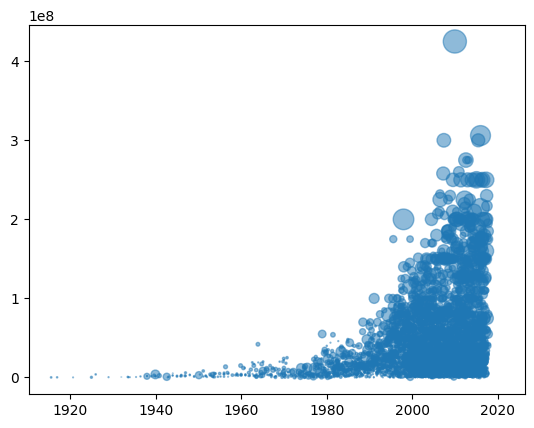

In [14]:
ypoints = data["USD_Production_Budget"]
xpoints = data["Release_Date"]
zpoints = data["USD_Worldwide_Gross"]
plt.scatter(
    xpoints,
    ypoints,
    s=zpoints / 1e7,  # adjust scaling factor
    alpha=0.5
)
plt.show()

# Converting Years to Decades Trick

**Challenge**: Create a column in `data_clean` that has the decade of the release. 

<img src=https://i.imgur.com/0VEfagw.png width=650> 

Here's how: 
1. Create a [`DatetimeIndex` object](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DatetimeIndex.html) from the Release_Date column. 
2. Grab all the years from the `DatetimeIndex` object using the `.year` property.
<img src=https://i.imgur.com/5m06Ach.png width=650>
3. Use floor division `//` to convert the year data to the decades of the films.
4. Add the decades as a `Decade` column to the `data_clean` DataFrame.

### Separate the "old" (before 1969) and "New" (1970s onwards) Films

**Challenge**: Create two new DataFrames: `old_films` and `new_films`
* `old_films` should include all the films before 1969 (up to and including 1969)
* `new_films` should include all the films from 1970 onwards
* How many films were released prior to 1970?
* What was the most expensive film made prior to 1970?

In [31]:
old_films = data[
    (data["Release_Date"].dt.year <= 1969)
]

from sklearn.linear_model import LinearRegression

X = old_films[["USD_Production_Budget"]]
y = old_films["USD_Worldwide_Gross"]

model = LinearRegression()
model.fit(X, y)

print(model.score(X, y))  # R²

0.02937258620576877


     Rank Release_Date                         Movie_Title  \
0    5293   1915-08-02               The Birth of a Nation   
1    5140   1916-05-09                         Intolerance   
2    5230   1916-12-24        20,000 Leagues Under the Sea   
3    5299   1920-09-17      Over the Hill to the Poorhouse   
4    5222   1925-01-01                      The Big Parade   
..    ...          ...                                 ...   
148  2375   1969-10-15                    Paint Your Wagon   
149  3831   1969-10-24  Butch Cassidy and the Sundance Kid   
150  2175   1969-12-16                        Hello, Dolly   
151  3613   1969-12-18     On Her Majesty's Secret Service   
152  4195   1969-12-19                               Topaz   

     USD_Production_Budget  USD_Worldwide_Gross  USD_Domestic_Gross  
0                   110000             11000000            10000000  
1                   385907                    0                   0  
2                   200000              80000

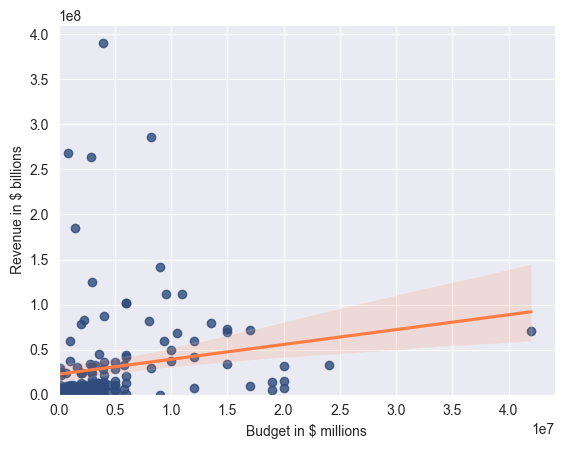

In [26]:
old_films = data[
    (data["Release_Date"].dt.year <= 1969)
]
print(old_films)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
sns.regplot(
    data=old_films,
    x="USD_Production_Budget",
    y="USD_Worldwide_Gross",
    scatter_kws={"color": "#2f4b7c"},  # dark blue dots
    line_kws={"color": "#ff7c43"}      # orange regression line
)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.xlabel("Budget in $ millions")
plt.ylabel("Revenue in $ billions")
plt.show()

In [32]:
new_films = data[
    (data["Release_Date"].dt.year >= 1970)
]
print(new_films)
X = new_films[["USD_Production_Budget"]]
y = new_films["USD_Worldwide_Gross"]

model = LinearRegression()
model.fit(X, y)

print(model.score(X, y))  # R²

      Rank Release_Date                     Movie_Title  \
153   2159   1970-01-01                        Waterloo   
154   2270   1970-01-01                    Darling Lili   
155   3136   1970-01-01                          Patton   
156   3277   1970-01-01              The Molly Maguires   
157   4265   1970-01-01                         M*A*S*H   
...    ...          ...                             ...   
5386  2950   2018-10-08                             Meg   
5387   126   2018-12-18                         Aquaman   
5388    96   2020-12-31                     Singularity   
5389  1119   2020-12-31          Hannibal the Conqueror   
5390  2517   2020-12-31  Story of Bonnie and Clyde, The   

      USD_Production_Budget  USD_Worldwide_Gross  USD_Domestic_Gross  
153                25000000                    0                   0  
154                22000000              5000000             5000000  
155                12000000             62500000            62500000  
156    

In [17]:
print(f"Number of films that were released before 1970 = {len(old_films)}")

Number of films that were released before 1970 = 153


In [18]:
max_old_budget = old_films["USD_Production_Budget"].max()
old_films[old_films["USD_Production_Budget"] == max_old_budget]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
109,1253,1963-12-06,Cleopatra,42000000,71000000,57000000


# Seaborn Regression Plots

**Challenge**: Use Seaborn's `.regplot()` to show the scatter plot and linear regression line against the `new_films`. 
<br>
<br>
Style the chart

* Put the chart on a `'darkgrid'`.
* Set limits on the axes so that they don't show negative values.
* Label the axes on the plot "Revenue in \$ billions" and "Budget in \$ millions".
* Provide HEX colour codes for the plot and the regression line. Make the dots dark blue (#2f4b7c) and the line orange (#ff7c43).

Interpret the chart

* Do our data points for the new films align better or worse with the linear regression than for our older films?
* Roughly how much would a film with a budget of $150 million make according to the regression line?

Yes, new films do better new_films R^2 = 0.5529880674636849 and old films = 0.02937258620576877

As I can see from the Graph a new film with $150M budget acoording to regression line will make $0.5 Billion  

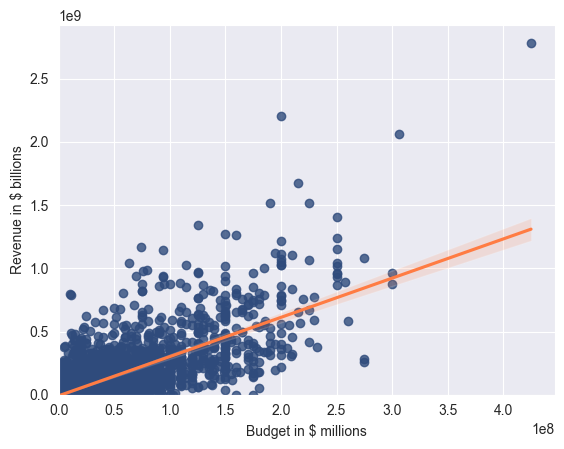

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
sns.regplot(
    data=new_films,
    x="USD_Production_Budget",
    y="USD_Worldwide_Gross",
    scatter_kws={"color": "#2f4b7c"},  # dark blue dots
    line_kws={"color": "#ff7c43"}      # orange regression line
)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.xlabel("Budget in $ millions")
plt.ylabel("Revenue in $ billions")
plt.show()

# Run Your Own Regression with scikit-learn

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

**Challenge**: Run a linear regression for the `old_films`. Calculate the intercept, slope and r-squared. How much of the variance in movie revenue does the linear model explain in this case?

In [44]:
x = pd.DataFrame(old_films, columns=["USD_Production_Budget"])
y = pd.DataFrame(old_films, columns=["USD_Worldwide_Gross"])
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y)
print(f"Intercept  = {model.intercept_}, Slope = {model.coef_} R^2 = {model.score(x,y)}")

Intercept  = [22821538.63508039], Slope = [[1.64771314]] R^2 = 0.02937258620576877


Only about 2.9% of the variation in movie revenue is explained by production budget.

# Use Your Model to Make a Prediction

We just estimated the slope and intercept! Remember that our Linear Model has the following form:

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

**Challenge**:  How much global revenue does our model estimate for a film with a budget of $350 million? 

In [47]:
print(model.predict([[350_000_000]]))

[[5.99521139e+08]]


c:\Users\Aman Basoya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Prediction = [[5.99521139e+08]] for $350M Budget